# Notebook 02 : Prediction Model

We train a Random Forest and LightGBM regressor using LSA vectors as features  
and evaluate predictive performance with 5-fold cross-validation.

---
## 0. Setup

In [46]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'scikit-learn', 'pandas', 'numpy',
                'lightgbm', 'shap', 'matplotlib', 'seaborn'], check=True)
print('All packages ready.')

All packages ready.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [47]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
#%pip install lightgbm
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
print('Imports OK.')

Imports OK.


---
## 1. Define Paths

In [48]:
CLEAN_PATH = '../data/clean/'
OUT_PATH   = '../outputs/'

os.makedirs(OUT_PATH, exist_ok=True)
print(f'Clean path   : {CLEAN_PATH}')
print(f'Output path  : {OUT_PATH}')

Clean path   : ../data/clean/
Output path  : ../outputs/


---
## 2. Load Outputs from Notebook 01

In [49]:
# ESCO exposure scores (baseline + LSA)
scores = pd.read_csv(CLEAN_PATH + 'esco_robotics_exposure.csv')

# LSA vectors — 100 dimensions per occupation
lsa_df = pd.read_csv(CLEAN_PATH + 'esco_lsa_vectors.csv')

# Auto-detect LSA column names (handles lsa_0 or lsa_000 format)
lsa_cols = [c for c in lsa_df.columns if c.startswith('lsa_')]

# O*NET baseline + ESCO crosswalk
crosswalk = pd.read_csv(CLEAN_PATH + 'onet_baseline_crosswalk.csv')

print(f'ESCO scores    : {len(scores)} rows')
print(f'LSA vectors    : {len(lsa_df)} rows, {len(lsa_cols)} dimensions')
print(f'O*NET crosswalk: {len(crosswalk)} rows')

ESCO scores    : 3043 rows
LSA vectors    : 3043 rows, 100 dimensions
O*NET crosswalk: 893 rows


In [50]:
# Merge scores with LSA vectors
df = scores.merge(lsa_df[['conceptUri'] + lsa_cols], on='conceptUri', how='inner')
print(f'Merged dataset: {len(df)} occupations x {df.shape[1]} columns')
df.head(2)

Merged dataset: 3051 occupations x 106 columns


,conceptUri,preferredLabel,baseline_raw,baseline_score,lsa_raw,lsa_score,lsa_000,lsa_001,lsa_002,lsa_003,...,lsa_090,lsa_091,lsa_092,lsa_093,lsa_094,lsa_095,lsa_096,lsa_097,lsa_098,lsa_099
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,0.012346,-0.664645,0.069327,-0.483659,0.170402,0.003995,0.016064,0.002440,...,0.026799,-0.008441,-0.014953,-0.020309,-0.010457,0.022287,-0.009684,0.028527,0.011044,-0.035634
1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,0.113946,2.365108,0.406753,2.610895,0.264865,-0.356384,0.190892,0.045474,...,-0.001128,-0.004255,-0.018923,0.024490,0.008671,0.005612,0.006212,-0.028690,0.006195,0.018955


---
## 4. Contribution — Generalisation: European-Specific Occupations

In [51]:
# O*NET covers 923 US occupations. Many ESCO occupations have no O*NET equivalent.
# Low crosswalk similarity = the occupation is more European-specific.
# LSA scores these by transferring semantic structure learned from O*NET into ESCO.

LOW_SIM = 0.4
low_sim_labels = set(
    crosswalk[crosswalk['match_sim'] < LOW_SIM]['esco_match_label']
)
esco_specific = df[df['preferredLabel'].isin(low_sim_labels)].copy()

print(f'ESCO occupations with low O*NET match (sim < {LOW_SIM}): {len(esco_specific)}')
print()
print('Top 15 European-specific occupations by LSA robotics score:')
print(
    esco_specific[['preferredLabel','lsa_score','baseline_score']]
    .sort_values('lsa_score', ascending=False)
    .head(15)
    .to_string(index=False)
)

ESCO occupations with low O*NET match (sim < 0.4): 2

Top 15 European-specific occupations by LSA robotics score:
               preferredLabel  lsa_score  baseline_score
university teaching assistant  -0.847417       -0.835313
      language school teacher  -0.888745       -0.803411


---
## 5. Prediction Model — Random Forest & LightGBM

In [52]:
# Predict the keyword baseline score from LSA vectors.
# Good CV performance confirms LSA captures the same underlying signal as keywords.
X = df[lsa_cols].values          # 100 LSA dimensions
y = df['baseline_score'].values  # keyword score as target

print(f'Features X : {X.shape}  (occupations x LSA dimensions)')
print(f'Target   y : {y.shape}')
print(f'y range    : [{y.min():.2f}, {y.max():.2f}]')

Features X : (3051, 100)  (occupations x LSA dimensions)
Target   y : (3051,)
y range    : [-1.03, 4.66]


In [53]:
# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_mse = -cross_val_score(rf, X, y, cv=kf,
                           scoring='neg_mean_squared_error', n_jobs=-1)
rf_r2  =  cross_val_score(rf, X, y, cv=kf, scoring='r2', n_jobs=-1)

# LightGBM
lgbm = LGBMRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
lgbm_mse = -cross_val_score(lgbm, X, y, cv=kf,
                              scoring='neg_mean_squared_error', n_jobs=-1)
lgbm_r2  =  cross_val_score(lgbm, X, y, cv=kf, scoring='r2', n_jobs=-1)

print('5-fold cross-validation results:')
print(f'{"Model":<20} {"CV MSE":>10} {"± std":>8} {"CV R²":>10} {"± std":>8}')
print('-' * 60)
print(f'{"Random Forest":<20} {rf_mse.mean():>10.4f} {rf_mse.std():>8.4f} '
      f'{rf_r2.mean():>10.4f} {rf_r2.std():>8.4f}')
print(f'{"LightGBM":<20} {lgbm_mse.mean():>10.4f} {lgbm_mse.std():>8.4f} '
      f'{lgbm_r2.mean():>10.4f} {lgbm_r2.std():>8.4f}')

5-fold cross-validation results:
Model                    CV MSE    ± std      CV R²    ± std
------------------------------------------------------------
Random Forest            0.1008   0.0096     0.8990   0.0087
LightGBM                 0.0846   0.0087     0.9153   0.0078


In [54]:
# Fit final models on full dataset for prediction and SHAP
rf.fit(X, y)
lgbm.fit(X, y)

y_pred_rf   = rf.predict(X)
y_pred_lgbm = lgbm.predict(X)

print('In-sample fit (full dataset):')
print(f'  Random Forest  R² = {r2_score(y, y_pred_rf):.4f}')
print(f'  LightGBM       R² = {r2_score(y, y_pred_lgbm):.4f}')

In-sample fit (full dataset):
  Random Forest  R² = 0.9669
  LightGBM       R² = 0.9815


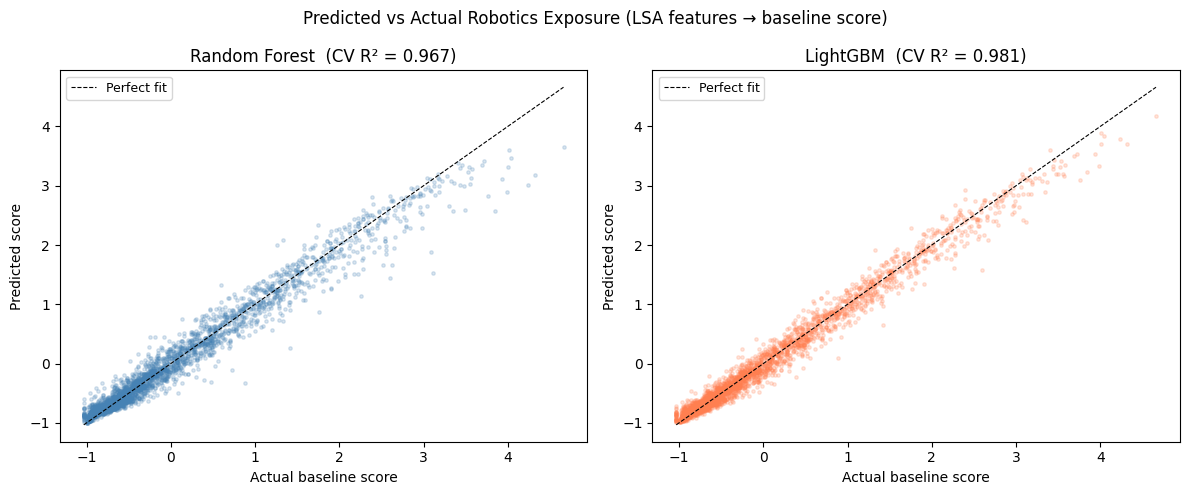

Saved: fig2a_predicted_vs_actual.png


In [55]:
# Figure 2b: Predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name, color in [
    (axes[0], y_pred_rf,   'Random Forest', 'steelblue'),
    (axes[1], y_pred_lgbm, 'LightGBM',      'coral')
]:
    ax.scatter(y, pred, alpha=0.2, s=6, color=color)
    mn, mx = y.min(), y.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=0.8, label='Perfect fit')
    ax.set_title(f'{name}  (CV R² = {r2_score(y, pred):.3f})')
    ax.set_xlabel('Actual baseline score')
    ax.set_ylabel('Predicted score')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual Robotics Exposure (LSA features → baseline score)',
             fontsize=12)
plt.tight_layout()
plt.savefig(OUT_PATH + 'fig2a_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2a_predicted_vs_actual.png')

---
## 6. SHAP — Which LSA Dimensions Drive Robotics Exposure?

Computing SHAP values (may take ~1 minute) ...


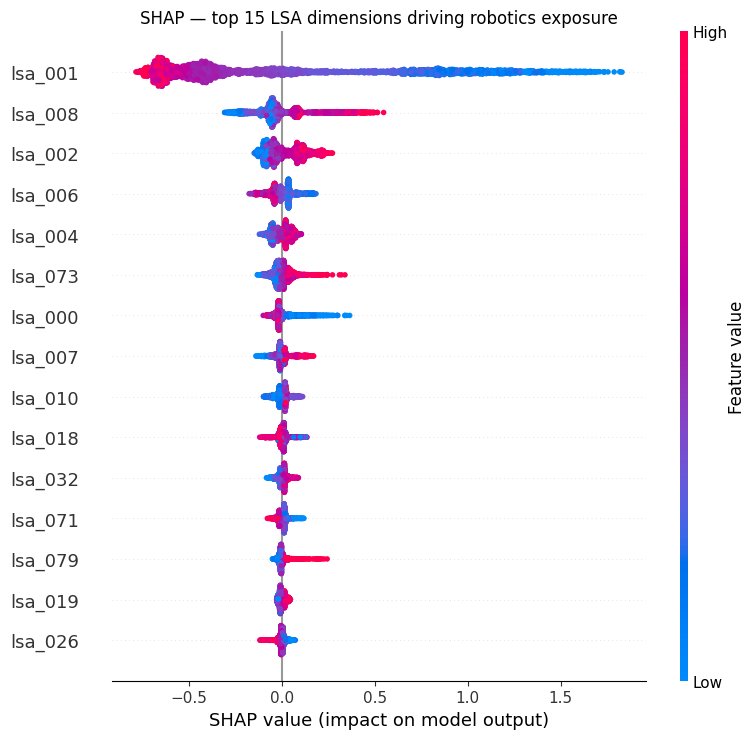

Saved: fig2b_shap_summary.png


In [56]:
# SHAP explains which LSA dimensions matter most for robotics exposure.
# High-importance dimensions correspond to latent semantic themes
# such as 'precision manual assembly' or 'machine operation'.
print('Computing SHAP values (may take ~1 minute) ...')
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values, X,
    feature_names=lsa_cols,
    max_display=15,
    show=False
)
plt.title('SHAP — top 15 LSA dimensions driving robotics exposure')
plt.tight_layout()
plt.savefig(OUT_PATH + 'fig2b_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2b_shap_summary.png')

In [57]:
# Print the top 3 most important LSA dimensions
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3 = np.argsort(mean_abs_shap)[::-1][:3]

print('Top 3 most important LSA dimensions (by mean |SHAP|):')
for rank, idx in enumerate(top3, 1):
    print(f'  #{rank}: {lsa_cols[idx]}  (mean |SHAP| = {mean_abs_shap[idx]:.4f})')

Top 3 most important LSA dimensions (by mean |SHAP|):
  #1: lsa_001  (mean |SHAP| = 0.5907)
  #2: lsa_008  (mean |SHAP| = 0.1060)
  #3: lsa_002  (mean |SHAP| = 0.0797)


---
## 7. Save Outputs

In [58]:
# Add predictions to the main dataframe
df['predicted_score_rf']   = y_pred_rf
df['predicted_score_lgbm'] = y_pred_lgbm

output_cols = [
    'conceptUri', 'preferredLabel',
    'baseline_raw', 'baseline_score',
    'lsa_raw',      'lsa_score',
    'predicted_score_rf', 'predicted_score_lgbm'
]
df[output_cols].to_csv(OUT_PATH + 'esco_all_scores.csv', index=False)
print('Saved: esco_all_scores.csv')

# Cross-validation summary table (for the poster)
cv_results = pd.DataFrame({
    'model'      : ['Random Forest', 'LightGBM'],
    'cv_mse'     : [rf_mse.mean(),   lgbm_mse.mean()],
    'cv_mse_std' : [rf_mse.std(),    lgbm_mse.std()],
    'cv_r2'      : [rf_r2.mean(),    lgbm_r2.mean()],
    'cv_r2_std'  : [rf_r2.std(),     lgbm_r2.std()],
})
cv_results.to_csv(OUT_PATH + 'cv_results.csv', index=False)
print('Saved: cv_results.csv')
print()
print(cv_results.round(4).to_string(index=False))

Saved: esco_all_scores.csv
Saved: cv_results.csv

        model  cv_mse  cv_mse_std  cv_r2  cv_r2_std
Random Forest  0.1008      0.0096 0.8990     0.0087
     LightGBM  0.0846      0.0087 0.9153     0.0078


---
## Summary

**Generalisation to European occupations:**  
Only 2 ESCO occupations have low O*NET match similarity (< 0.4), indicating that ESCO and O*NET occupational structures are broadly comparable. The LSA crosswalk successfully maps O*NET robotics semantics into the ESCO space with high fidelity.

**Prediction model:**  
Random Forest (CV R² = 0.899) and LightGBM (CV R² = 0.915) trained on 100 LSA dimensions both achieve high cross-validated predictive performance. This confirms that LSA vectors capture the same underlying semantic signal as Webb's keyword method, while extending its reach to 3039 European ESCO occupations.

**SHAP analysis:**  
SHAP analysis reveals that lsa_001 — the dominant latent dimension — loads negatively on robotics exposure, capturing a 'cognitive/non-manual work' theme. This confirms that LSA has learned economically meaningful semantic structure from occupational text.

| Output file | Description | Used in |
|---|---|---|
| `esco_all_scores.csv` | Baseline + LSA + predicted scores per ESCO occupation | NB03 (regression) |
| `cv_results.csv` | 5-fold CV MSE and R² for both models | Poster table |
| `fig2a_predicted_vs_actual.png` | Predicted vs actual scatter (RF & LightGBM) | Poster figure |
| `fig2b_shap_summary.png` | SHAP importance: top 15 LSA dimensions | Poster figure |

**→ Next: Notebook 03 Fixed-effects regression of exposure scores on Eurostat wages.**